In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
pip install numpy pandas matplotlib tqdm scikit-learn scikit-image scipy opencv-python seaborn tensorflow joblib


In [3]:
# =========================
# Cell 1: Imports
# =========================
import os
import gc
import cv2
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from skimage.filters import gabor
from skimage.feature import hog

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization,
    Dense, Dropout, GlobalAveragePooling2D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

np.random.seed(42)
tf.random.set_seed(42)
plt.style.use("ggplot")


In [4]:
# =========================
# Cell 2: Config
# =========================
DATASET_1_PATH = "/content/drive/MyDrive/Colab Notebooks/dataset_1"
DATASET_2_PATH = "/content/drive/MyDrive/Colab Notebooks/dataset_2"

IMG_SIZE = (128, 128)
BATCH_SIZE = 16
MAX_MODEL_MB = 24.0

MODEL_DIR = "saved_models"
os.makedirs(MODEL_DIR, exist_ok=True)


In [5]:
# =========================
# Cell 3: Helpers
# =========================
def get_file_size_mb(path: str) -> float:
    return os.path.getsize(path) / (1024 * 1024)

def save_keras_checked(model, path: str, max_mb: float = MAX_MODEL_MB):
    model.save(path, include_optimizer=False)
    size_mb = get_file_size_mb(path)
    print(f"[SIZE] {os.path.basename(path)}: {size_mb:.2f} MB")
    if size_mb > max_mb:
        raise ValueError(f"{path} is {size_mb:.2f} MB (> {max_mb} MB)")

def plot_conf_matrix(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

def plot_multiclass_roc(y_true, y_prob, class_names, title):
    y_bin = label_binarize(y_true, classes=np.arange(len(class_names)))
    plt.figure(figsize=(7, 6))
    plotted = 0
    for i, cls in enumerate(class_names):
        if np.sum(y_bin[:, i]) == 0:
            continue
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"{cls} (AUC={roc_auc:.3f})")
        plotted += 1
    plt.plot([0, 1], [0, 1], "k--", lw=1)
    plt.title(title)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    if plotted > 0:
        plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

def evaluate_and_report(model_name, y_true, y_pred, y_prob, class_names):
    acc = accuracy_score(y_true, y_pred)
    print(f"\n[{model_name}] Accuracy: {acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=class_names))
    plot_conf_matrix(y_true, y_pred, class_names, f"{model_name} - Confusion Matrix")
    plot_multiclass_roc(y_true, y_prob, class_names, f"{model_name} - ROC (OvR)")
    return acc

def plot_history(history, title_prefix):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train")
    plt.plot(history.history["val_accuracy"], label="Val")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train")
    plt.plot(history.history["val_loss"], label="Val")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

def train_rf_under_size_limit(
    X_train_feat, y_train, X_test_feat,
    save_path, random_state=42, max_mb=MAX_MODEL_MB,
    candidates=((160, 20), (120, 18), (100, 16), (80, 14), (60, 12))
):
    chosen_model = None
    for n_estimators, max_depth in candidates:
        print(f"Trying RF: n_estimators={n_estimators}, max_depth={max_depth}")
        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_leaf=2,
            random_state=random_state,
            n_jobs=-1
        )
        model.fit(X_train_feat, y_train)
        joblib.dump(model, save_path, compress=5)
        size_mb = get_file_size_mb(save_path)
        print(f"[SIZE] {os.path.basename(save_path)}: {size_mb:.2f} MB")
        if size_mb <= max_mb:
            chosen_model = model
            break

    if chosen_model is None:
        raise ValueError(f"Could not fit RF model under {max_mb} MB. Try smaller candidates.")

    y_prob = chosen_model.predict_proba(X_test_feat)
    y_pred = np.argmax(y_prob, axis=1)
    return chosen_model, y_pred, y_prob


In [6]:
# =========================
# Cell 4: Load data
# =========================
def load_fingerprint_dataset(base_path, img_size=(128, 128)):
    images, labels = [], []
    classes = sorted(os.listdir(base_path))

    for label in classes:
        class_path = os.path.join(base_path, label)
        if not os.path.isdir(class_path):
            continue

        for img_name in tqdm(os.listdir(class_path), desc=f"Loading {label}"):
            img_path = os.path.join(class_path, img_name)
            try:
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                img = cv2.resize(img, img_size)
                images.append(img)
                labels.append(label)
            except Exception:
                continue

    return np.array(images), np.array(labels)

X1, y1 = load_fingerprint_dataset(DATASET_1_PATH, IMG_SIZE)
X2, y2 = load_fingerprint_dataset(DATASET_2_PATH, IMG_SIZE)

X = np.concatenate([X1, X2], axis=0).astype(np.float32) / 255.0
y = np.concatenate([y1, y2], axis=0)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("X:", X.shape, "y:", y_encoded.shape)
print("Classes:", list(label_encoder.classes_))


Loading O-: 100%|██████████| 712/712 [00:25<00:00, 27.98it/s] 


X: (13932, 128, 128) y: (13932,)
Classes: [np.str_('A+'), np.str_('A-'), np.str_('AB+'), np.str_('AB-'), np.str_('B+'), np.str_('B-'), np.str_('O+'), np.str_('O-')]


In [7]:
# =========================
# Cell 5: Enhancement
# =========================
def enhance_fingerprint(img):
    img_u8 = (img * 255).astype(np.uint8)
    img_denoised = cv2.GaussianBlur(img_u8, (5, 5), 0)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_clahe = clahe.apply(img_denoised)
    blur = cv2.GaussianBlur(img_clahe, (9, 9), 10)
    img_sharp = cv2.addWeighted(img_clahe, 1.5, blur, -0.5, 0)
    return img_sharp.astype(np.float32) / 255.0

X_enhanced = np.array([enhance_fingerprint(img) for img in tqdm(X)], dtype=np.float32)
print("Enhanced:", X_enhanced.shape)


100%|██████████| 13932/13932 [00:13<00:00, 1055.98it/s]


Enhanced: (13932, 128, 128)


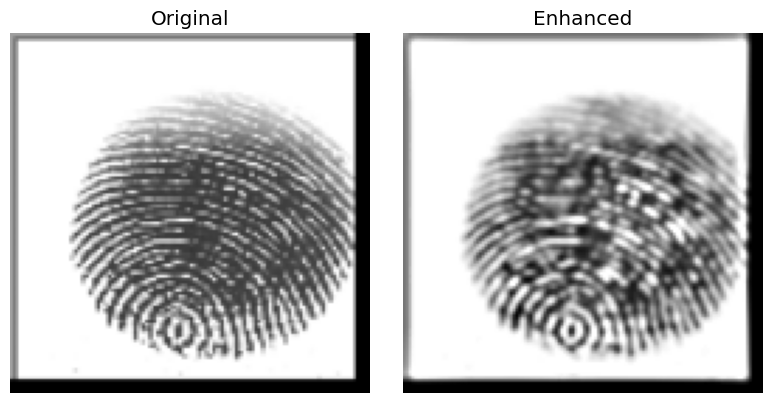

In [8]:
# =========================
# New Cell: Show Original vs Enhanced Image
# =========================
idx = np.random.randint(0, len(X))  # random sample index

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(X[idx], cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(X_enhanced[idx], cmap="gray")
plt.title("Enhanced")
plt.axis("off")

plt.tight_layout()
plt.show()


In [9]:
# =========================
# Cell 6: Split + class weights + generator prep
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X_enhanced, y_encoded,
    test_size=0.2, stratify=y_encoded, random_state=42
)

class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights_arr))

X_train_cnn = np.expand_dims(X_train, axis=-1)
X_test_cnn = np.expand_dims(X_test, axis=-1)

train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)
test_datagen = ImageDataGenerator()

train_gen_gray = train_datagen.flow(
    X_train_cnn, y_train, batch_size=BATCH_SIZE, shuffle=True
)
test_gen_gray = test_datagen.flow(
    X_test_cnn, y_test, batch_size=BATCH_SIZE, shuffle=False
)

def to_rgb_preprocessed_generator(gen):
    while True:
        xb, yb = next(gen)                  # (B,128,128,1)
        xb = np.repeat(xb, 3, axis=-1)     # (B,128,128,3)
        xb = preprocess_input(xb * 255.0)
        yield xb, yb

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)


Train: (11145, 128, 128) (11145,)
Test : (2787, 128, 128) (2787,)


In [10]:
# =========================
# Cell 7: Feature extractors (classical models)
# =========================
def extract_hog_features(images):
    feats = []
    for img in tqdm(images, desc="HOG"):
        f = hog(
            img,
            orientations=9,
            pixels_per_cell=(16, 16),
            cells_per_block=(2, 2),
            block_norm="L2-Hys"
        )
        feats.append(f)
    return np.array(feats, dtype=np.float32)

def extract_gabor_features(images, frequencies=(0.1, 0.3, 0.5)):
    feats = []
    for img in tqdm(images, desc="Gabor"):
        vals = []
        for freq in frequencies:
            real, imag = gabor(img, frequency=freq)
            vals += [real.mean(), real.var(), imag.mean(), imag.var()]
        feats.append(vals)
    return np.array(feats, dtype=np.float32)

X_train_hog = extract_hog_features(X_train)
X_test_hog = extract_hog_features(X_test)

X_train_gabor = extract_gabor_features(X_train)
X_test_gabor = extract_gabor_features(X_test)


Gabor: 100%|██████████| 2787/2787 [05:50<00:00,  7.96it/s]


Trying RF: n_estimators=160, max_depth=20
[SIZE] rf_hog.joblib: 6.79 MB

[HOG + RandomForest] Accuracy: 0.9458
              precision    recall  f1-score   support

          A+       0.97      0.92      0.94       311
          A-       0.98      0.97      0.97       400
         AB+       0.93      0.93      0.93       340
         AB-       0.92      0.96      0.94       353
          B+       0.92      0.90      0.91       328
          B-       0.96      0.96      0.96       346
          O+       0.97      0.97      0.97       369
          O-       0.91      0.95      0.93       340

    accuracy                           0.95      2787
   macro avg       0.95      0.94      0.94      2787
weighted avg       0.95      0.95      0.95      2787



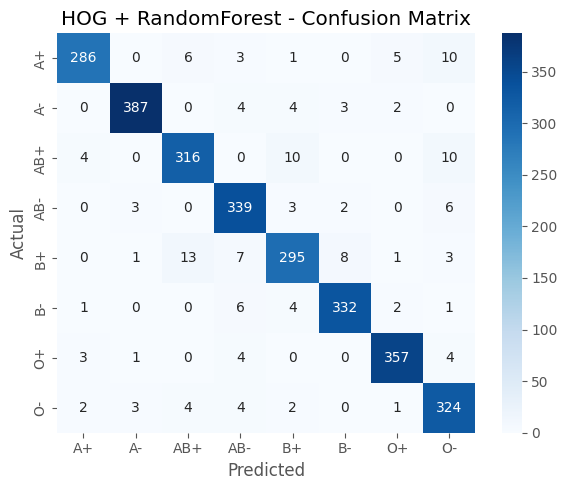

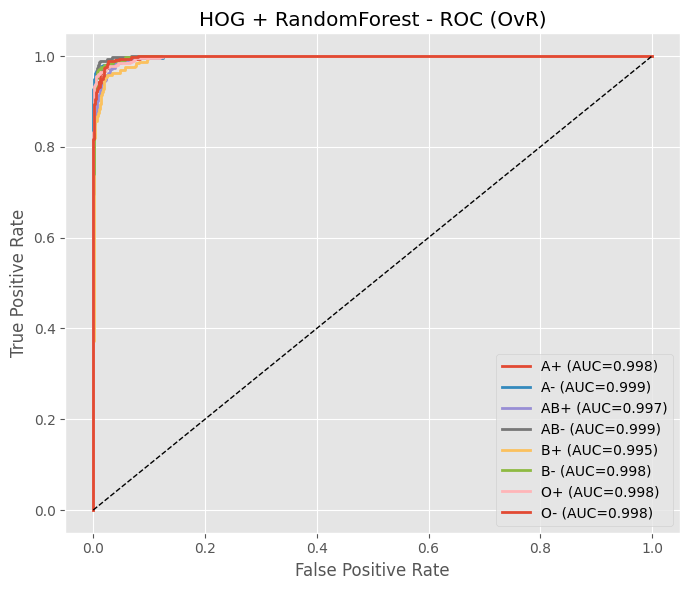

In [11]:
# =========================
# Cell 8: Model 1 - HOG + RF (train/eval/save)
# =========================
rf_hog_path = os.path.join(MODEL_DIR, "rf_hog.joblib")
rf_hog, rf_hog_pred, rf_hog_prob = train_rf_under_size_limit(
    X_train_hog, y_train, X_test_hog, rf_hog_path
)

acc_rf_hog = evaluate_and_report(
    "HOG + RandomForest", y_test, rf_hog_pred, rf_hog_prob, label_encoder.classes_
)


Trying RF: n_estimators=160, max_depth=20
[SIZE] rf_gabor.joblib: 15.21 MB

[Gabor + RandomForest] Accuracy: 0.7664
              precision    recall  f1-score   support

          A+       0.71      0.68      0.70       311
          A-       0.80      0.84      0.82       400
         AB+       0.71      0.77      0.74       340
         AB-       0.81      0.79      0.80       353
          B+       0.70      0.78      0.74       328
          B-       0.76      0.76      0.76       346
          O+       0.81      0.74      0.77       369
          O-       0.83      0.74      0.78       340

    accuracy                           0.77      2787
   macro avg       0.77      0.76      0.76      2787
weighted avg       0.77      0.77      0.77      2787



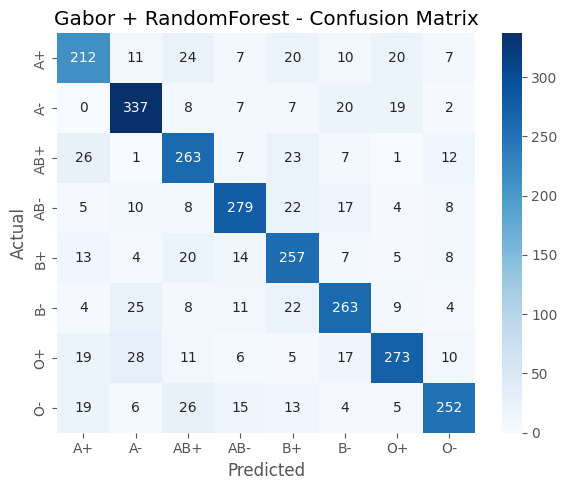

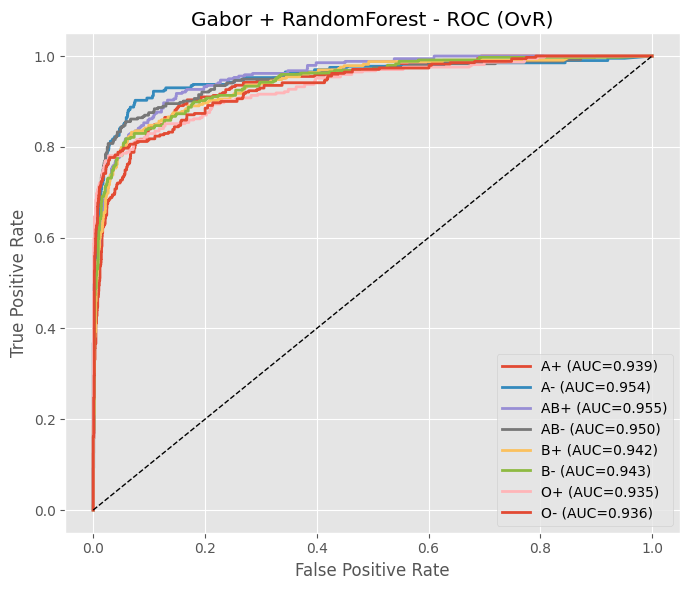

In [12]:
# =========================
# Cell 9: Model 2 - Gabor + RF (train/eval/save)
# =========================
rf_gabor_path = os.path.join(MODEL_DIR, "rf_gabor.joblib")
rf_gabor, rf_gabor_pred, rf_gabor_prob = train_rf_under_size_limit(
    X_train_gabor, y_train, X_test_gabor, rf_gabor_path
)

acc_rf_gabor = evaluate_and_report(
    "Gabor + RandomForest", y_test, rf_gabor_pred, rf_gabor_prob, label_encoder.classes_
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



=== Custom CNN Summary ===


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,344 (399.78 KB)

 Trainable params: 101,896 (398.03 KB)

 Non-trainable params: 448 (1.75 KB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
697/697 ━━━━━━━━━━━━━━━━━━━━ 523s 746ms/step - accuracy: 0.3045 - loss: 1.7477 - val_accuracy: 0.2063 - val_loss: 2.7289 - learning_rate: 0.0010
Epoch 2/20
697/697 ━━━━━━━━━━━━━━━━━━━━ 522s 750ms/step - accuracy: 0.4565 - loss: 1.3849 - val_accuracy: 0.2684 - val_loss: 3.4689 - learning_rate: 0.0010
Epoch 3/20
697/697 ━━━━━━━━━━━━━━━━━━━━ 517s 741ms/step - accuracy: 0.5467 - loss: 1.1738 - val_accuracy: 0.3760 - val_loss: 1.7994 - learning_rate: 0.0010
Epoch 4/20
697/697 ━━━━━━━━━━━━━━━━━━━━ 519s 744ms/step - accuracy: 0.5931 - loss: 1.0735 - val_accuracy: 0.5691 - val_loss: 1.1146 - learning_rate: 0.0010
Epoch 5/20
697/697 ━━━━━━━━━━━━━━━━━━━━ 581s 772ms/step - accuracy: 0.6313 - loss: 0.9755 - val_accuracy: 0.5612 - val_loss: 2.1009 - learning_rate: 0.0010
Epoch 6/20
697/697 ━━━━━━━━━━━━━━━━━━━━ 519s 745ms/step - accuracy: 0.6559 - loss: 0.9261 - val_accuracy: 0.4277 - val_loss: 1.6335 - learning_rate: 0.0010
Epoch 7/20
697/697 ━━━━━━━━━━━━━━━━━━━━ 522s 749ms/step - accura

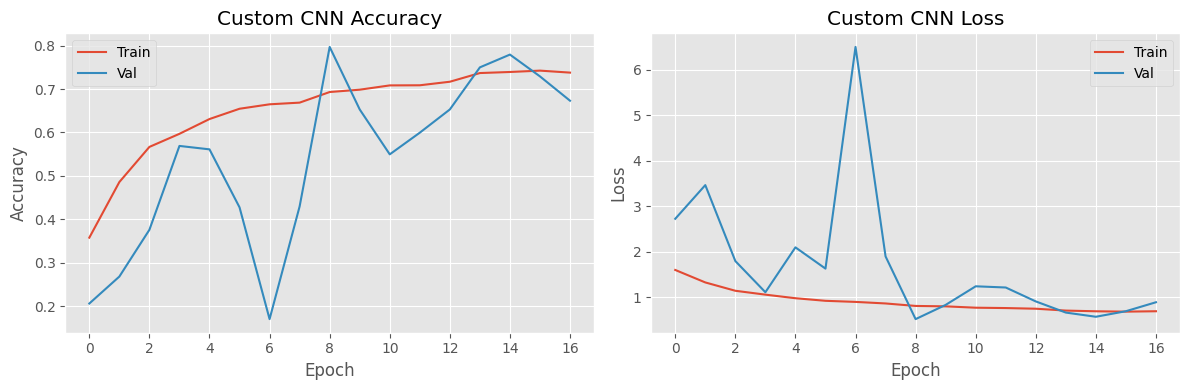

175/175 ━━━━━━━━━━━━━━━━━━━━ 26s 146ms/step

[Custom CNN] Accuracy: 0.7969
              precision    recall  f1-score   support

          A+       0.86      0.87      0.87       311
          A-       0.71      0.85      0.77       400
         AB+       0.83      0.73      0.78       340
         AB-       0.81      0.71      0.76       353
          B+       0.91      0.73      0.81       328
          B-       0.83      0.92      0.87       346
          O+       0.78      0.80      0.79       369
          O-       0.71      0.76      0.73       340

    accuracy                           0.80      2787
   macro avg       0.81      0.80      0.80      2787
weighted avg       0.80      0.80      0.80      2787



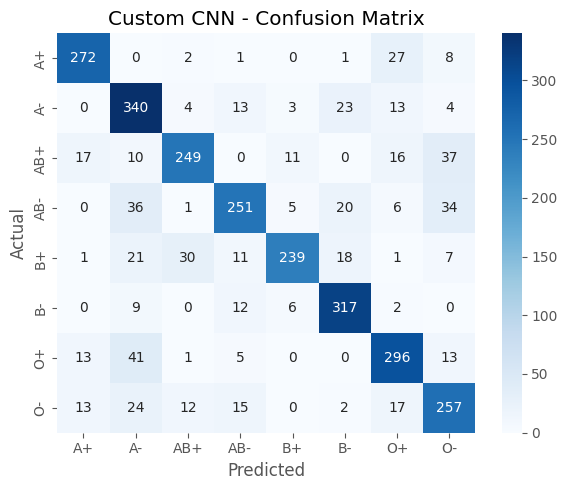

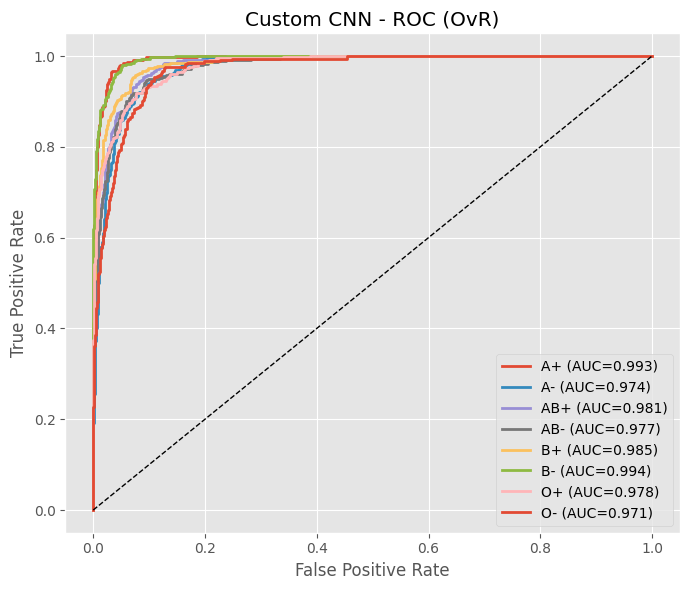

[SIZE] cnn_model.keras: 1.23 MB


In [13]:
# =========================
# Cell 10: Model 3 - Custom CNN (summary/train/eval/save)
# =========================
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(128, 128, 1)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    GlobalAveragePooling2D(),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(len(label_encoder.classes_), activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\n=== Custom CNN Summary ===")
cnn_model.summary()

early_stop = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6)

history_cnn = cnn_model.fit(
    train_gen_gray,
    validation_data=test_gen_gray,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

plot_history(history_cnn, "Custom CNN")

cnn_prob = cnn_model.predict(X_test_cnn, batch_size=BATCH_SIZE, verbose=1)
cnn_pred = np.argmax(cnn_prob, axis=1)

acc_cnn = evaluate_and_report(
    "Custom CNN", y_test, cnn_pred, cnn_prob, label_encoder.classes_
)

cnn_path = os.path.join(MODEL_DIR, "cnn_model.keras")
save_keras_checked(cnn_model, cnn_path)



=== MobileNetV2 Summary ===


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,340,488 (8.93 MB)

 Trainable params: 82,504 (322.28 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/12
697/697 ━━━━━━━━━━━━━━━━━━━━ 220s 292ms/step - accuracy: 0.3069 - loss: 1.7528 - val_accuracy: 0.4374 - val_loss: 1.3318 - learning_rate: 0.0010
Epoch 2/12
697/697 ━━━━━━━━━━━━━━━━━━━━ 200s 288ms/step - accuracy: 0.4231 - loss: 1.4064 - val_accuracy: 0.4850 - val_loss: 1.2526 - learning_rate: 0.0010
Epoch 3/12
697/697 ━━━━━━━━━━━━━━━━━━━━ 200s 287ms/step - accuracy: 0.4548 - loss: 1.3290 - val_accuracy: 0.4843 - val_loss: 1.2313 - learning_rate: 0.0010
Epoch 4/12
697/697 ━━━━━━━━━━━━━━━━━━━━ 201s 288ms/step - accuracy: 0.4606 - loss: 1.2988 - val_accuracy: 0.5185 - val_loss: 1.1388 - learning_rate: 0.0010
Epoch 5/12
697/697 ━━━━━━━━━━━━━━━━━━━━ 197s 282ms/step - accuracy: 0.4780 - loss: 1.2658 - val_accuracy: 0.5156 - val_loss: 1.1471 - learning_rate: 0.0010
Epoch 6/12
697/697 ━━━━━━━━━━━━━━━━━━━━ 198s 283ms/step - accuracy: 0.4710 - loss: 1.2727 - val_accuracy: 0.5152 - val_loss: 1.1487 - learning_rate: 0.0010
Epoch 7/12
697/697 ━━━━━━━━━━━━━━━━━━━━ 194s 279ms/step - accura

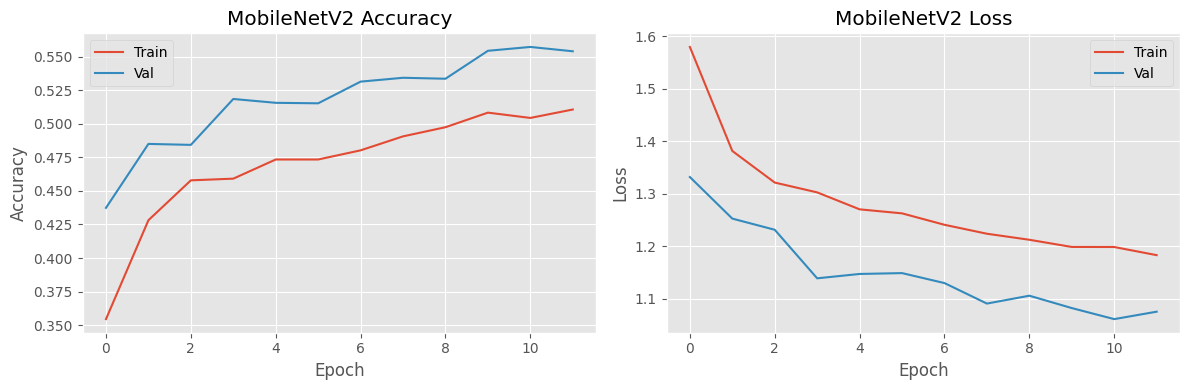

175/175 ━━━━━━━━━━━━━━━━━━━━ 39s 216ms/step

[MobileNetV2] Accuracy: 0.5583
              precision    recall  f1-score   support

          A+       0.65      0.68      0.66       311
          A-       0.47      0.69      0.56       400
         AB+       0.56      0.69      0.62       340
         AB-       0.58      0.62      0.60       353
          B+       0.54      0.32      0.40       328
          B-       0.64      0.76      0.69       346
          O+       0.48      0.29      0.36       369
          O-       0.57      0.42      0.49       340

    accuracy                           0.56      2787
   macro avg       0.56      0.56      0.55      2787
weighted avg       0.56      0.56      0.55      2787



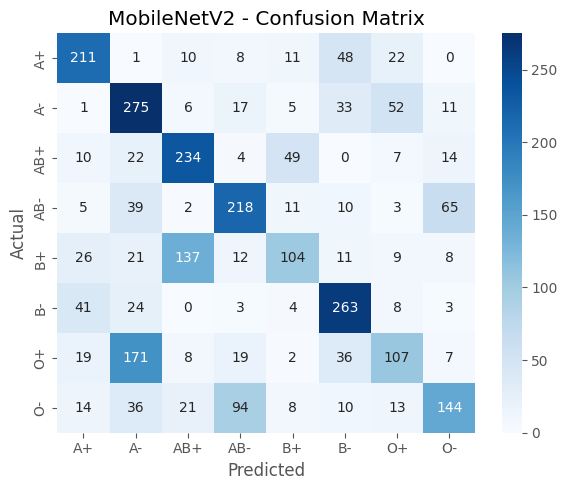

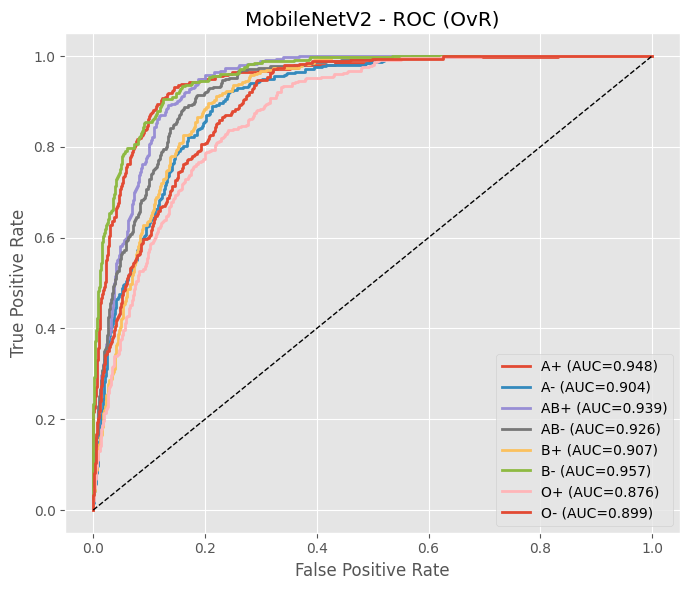

[SIZE] mobilenet_model.keras: 10.12 MB


In [16]:
# =========================
# Cell 11: Model 4 - MobileNetV2 (summary/train/eval/save)
# =========================
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(128, 128, 3)
)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(64, activation="relu")(x)
x = Dropout(0.3)(x)
out = Dense(len(label_encoder.classes_), activation="softmax")(x)

mobilenet_model = Model(inputs=base_model.input, outputs=out)

mobilenet_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\n=== MobileNetV2 Summary ===")
mobilenet_model.summary()

train_gen_gray.reset()
test_gen_gray.reset()

history_mnet = mobilenet_model.fit(
    to_rgb_preprocessed_generator(train_gen_gray),
    validation_data=to_rgb_preprocessed_generator(test_gen_gray),
    steps_per_epoch=len(train_gen_gray),
    validation_steps=len(test_gen_gray),
    epochs=12,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


plot_history(history_mnet, "MobileNetV2")

test_gen_gray.reset()
mnet_prob = mobilenet_model.predict(
    to_rgb_preprocessed_generator(test_gen_gray),
    steps=len(test_gen_gray),
    verbose=1
)
mnet_pred = np.argmax(mnet_prob, axis=1)

acc_mnet = evaluate_and_report(
    "MobileNetV2", y_test, mnet_pred, mnet_prob, label_encoder.classes_
)

mnet_path = os.path.join(MODEL_DIR, "mobilenet_model.keras")
save_keras_checked(mobilenet_model, mnet_path)


697/697 ━━━━━━━━━━━━━━━━━━━━ 115s 164ms/step
175/175 ━━━━━━━━━━━━━━━━━━━━ 27s 156ms/step
697/697 ━━━━━━━━━━━━━━━━━━━━ 140s 200ms/step
175/175 ━━━━━━━━━━━━━━━━━━━━ 34s 195ms/step

[Stacked Ensemble] Accuracy: 0.9559
              precision    recall  f1-score   support

          A+       0.96      0.96      0.96       311
          A-       0.99      0.96      0.98       400
         AB+       0.96      0.95      0.95       340
         AB-       0.94      0.97      0.95       353
          B+       0.94      0.93      0.93       328
          B-       0.95      0.97      0.96       346
          O+       0.97      0.96      0.96       369
          O-       0.93      0.96      0.94       340

    accuracy                           0.96      2787
   macro avg       0.96      0.96      0.96      2787
weighted avg       0.96      0.96      0.96      2787



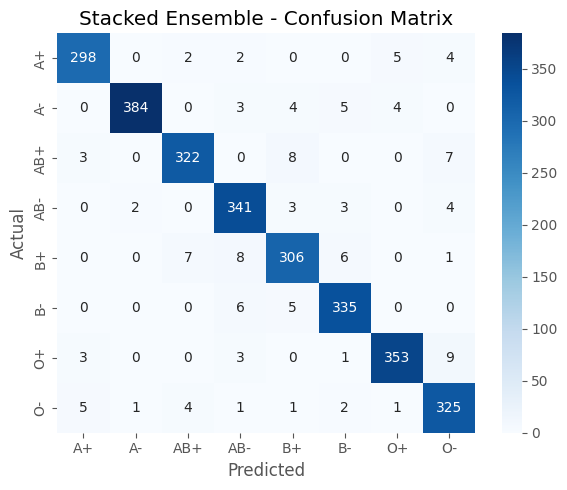

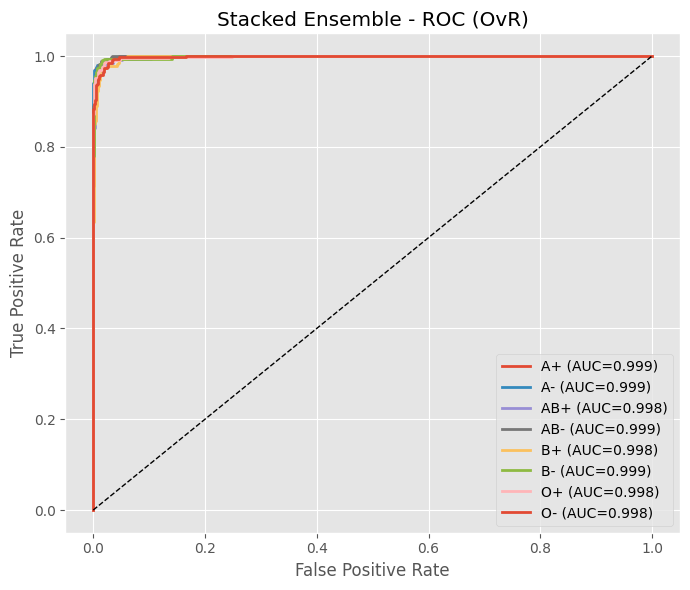

[SIZE] ensemble_logreg.joblib: 0.00 MB


In [17]:
# =========================
# Cell 12: Model 5 - Ensemble (train/eval/save)
# =========================
# Train/test probs for each base model
train_eval_gray = test_datagen.flow(
    X_train_cnn, y_train, batch_size=BATCH_SIZE, shuffle=False
)
test_eval_gray = test_datagen.flow(
    X_test_cnn, y_test, batch_size=BATCH_SIZE, shuffle=False
)

# Classical model probs
rf_hog_train_prob = rf_hog.predict_proba(X_train_hog)
rf_hog_test_prob = rf_hog.predict_proba(X_test_hog)

rf_gabor_train_prob = rf_gabor.predict_proba(X_train_gabor)
rf_gabor_test_prob = rf_gabor.predict_proba(X_test_gabor)

# Deep model probs
cnn_train_prob = cnn_model.predict(X_train_cnn, batch_size=BATCH_SIZE, verbose=1)
cnn_test_prob = cnn_model.predict(X_test_cnn, batch_size=BATCH_SIZE, verbose=1)

train_eval_gray.reset()
mnet_train_prob = mobilenet_model.predict(
    to_rgb_preprocessed_generator(train_eval_gray),
    steps=len(train_eval_gray),
    verbose=1
)

test_eval_gray.reset()
mnet_test_prob = mobilenet_model.predict(
    to_rgb_preprocessed_generator(test_eval_gray),
    steps=len(test_eval_gray),
    verbose=1
)

# Stacking
stack_train = np.concatenate(
    [rf_hog_train_prob, rf_gabor_train_prob, cnn_train_prob, mnet_train_prob], axis=1
)
stack_test = np.concatenate(
    [rf_hog_test_prob, rf_gabor_test_prob, cnn_test_prob, mnet_test_prob], axis=1
)

ensemble_model = LogisticRegression(max_iter=2000)
ensemble_model.fit(stack_train, y_train)

ens_prob = ensemble_model.predict_proba(stack_test)
ens_pred = np.argmax(ens_prob, axis=1)

acc_ens = evaluate_and_report(
    "Stacked Ensemble", y_test, ens_pred, ens_prob, label_encoder.classes_
)

ensemble_path = os.path.join(MODEL_DIR, "ensemble_logreg.joblib")
joblib.dump(ensemble_model, ensemble_path, compress=5)
print(f"[SIZE] {os.path.basename(ensemble_path)}: {get_file_size_mb(ensemble_path):.2f} MB")
if get_file_size_mb(ensemble_path) > MAX_MODEL_MB:
    raise ValueError("Ensemble model exceeds size limit.")


In [18]:
# =========================
# Cell 13: Save label encoder + results
# =========================
label_encoder_path = os.path.join(MODEL_DIR, "label_encoder.joblib")
joblib.dump(label_encoder, label_encoder_path, compress=5)

results = pd.DataFrame({
    "Model": [
        "HOG + RandomForest",
        "Gabor + RandomForest",
        "Custom CNN",
        "MobileNetV2",
        "Stacked Ensemble"
    ],
    "Accuracy": [
        acc_rf_hog,
        acc_rf_gabor,
        acc_cnn,
        acc_mnet,
        acc_ens
    ]
}).sort_values("Accuracy", ascending=False)

print(results)


                  Model  Accuracy
4      Stacked Ensemble  0.955867
0    HOG + RandomForest  0.945820
2            Custom CNN  0.796914
1  Gabor + RandomForest  0.766416
3           MobileNetV2  0.558306


In [19]:
# =========================
# Cell 14: Final size check (<24 MB for all)
# =========================
saved_files = [
    rf_hog_path,
    rf_gabor_path,
    cnn_path,
    mnet_path,
    ensemble_path,
    label_encoder_path
]

for p in saved_files:
    size_mb = get_file_size_mb(p)
    print(f"{os.path.basename(p):25s} -> {size_mb:6.2f} MB")
    if size_mb > MAX_MODEL_MB:
        raise ValueError(f"{p} exceeds {MAX_MODEL_MB} MB")

print("\nAll saved models are under 24 MB.")


rf_hog.joblib             ->   6.79 MB
rf_gabor.joblib           ->  15.21 MB
cnn_model.keras           ->   1.23 MB
mobilenet_model.keras     ->  10.12 MB
ensemble_logreg.joblib    ->   0.00 MB
label_encoder.joblib      ->   0.00 MB

All saved models are under 24 MB.


In [20]:
# =========================
# Cell 15: Optional cleanup
# =========================
del X_train_hog, X_test_hog, X_train_gabor, X_test_gabor
gc.collect()
print("Cleanup done.")


Cleanup done.
